In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('train.csv')
df.rename(columns={df.columns[0]: 'Location'}, inplace=True)
df.rename(columns={df.columns[1]: 'Date'}, inplace=True)
df.rename(columns={df.columns[2]: 'ItemName'}, inplace=True)
df['Date'] = pd.to_datetime(df['Date'], format='%Y/%m/%d')

def missingValueImputation(unit):
    unit[unit == '#' + ' '*30] = np.nan
    unit[unit == '*' + ' '*30] = np.nan
    unit[unit == 'x' + ' '*30] = np.nan
    unit[unit == 'A' + ' '*30] = np.nan
    
    new_unit = list()
    for index, row in enumerate(unit):
        row = row.astype(np.float32)
        indices = np.isnan(row)
        x = np.arange(len(row))
        
        if len(row[~indices]) != 0:
            row[indices] = np.interp(
                x[indices], 
                x[~indices], 
                row[~indices]
            )
        else:
            row[indices] = np.zeros(len(row)) + mean[index]
        
        new_unit.append([row])
    
    return np.concatenate(new_unit)

unit_size = 10
counter = 0

dataset, unit = list(), list()
for _, sdf in df.groupby('Date'):
    unit.append(np.array(sdf.iloc[:, 3:]))
    
    counter = (counter + 1) % unit_size
    if counter == 0:
        unit = np.concatenate(unit, axis=1)
        unit = missingValueImputation(unit)
        dataset.append(unit)
        unit = list()

print(f"Data unit of every {unit_size} days: {len(dataset)}")
print(f"Data size of each unit: {dataset[0].shape}")

Data unit of every 10 days: 24
Data size of each unit: (18, 240)


In [3]:
np.random.seed(816124)
np.random.shuffle(dataset)

trainSet = dataset[:int(len(dataset) * 0.8)]
validSet = dataset[int(len(dataset) * 0.8):]

unit_time = 9
def preprocessing(dataset, mean, std):
    X, Y = list(), list()
    for unit in dataset:
        for i in range(unit.shape[1] - unit_time):
            x = (unit[:, i:i+unit_time] - mean) / std
            X.append([x.flatten()])
            Y.append([unit[9, i+unit_time]])
            
    X = np.concatenate(X)
    Y = np.concatenate(Y)
    
    return X, Y

flattenSet = np.concatenate(trainSet, axis=1)
mean = np.mean(flattenSet, axis=1).reshape(-1, 1)
std = np.std(flattenSet, axis=1).reshape(-1, 1)
trainX, trainY = preprocessing(trainSet, mean, std)
validX, validY = preprocessing(validSet, mean, std)

indices = np.random.permutation(trainX.shape[0])
trainX, trainY = trainX[indices], trainY[indices]

print(f"Size of trainX: {trainX.shape}, trainY: {trainY.shape}")
print(f"Size of validX: {validX.shape}, validY: {validY.shape}")

Size of trainX: (4389, 162), trainY: (4389,)
Size of validX: (1155, 162), validY: (1155,)


In [4]:
class LinearRegression:
    
    def __init__(self):    
        self.epoch = []
        self.train_loss = []
        self.weights = None
        
    def constant_padding(self, X):
        return np.pad(X, ((0,0),(0,1)), 'constant', constant_values=(1))

    def fit(self, X, Y, lr=0.001, epochs=100, batch_size=64, lambd=0):
        
        X = self.constant_padding(X)
        self.weights = np.zeros(X.shape[1])
        
        for epoch in range(epochs):
            for batch in range(len(X)//batch_size+1):
                batchX = X[batch_size*batch: batch_size*(batch+1)]
                batchY = Y[batch_size*batch: batch_size*(batch+1)]
                predY = self.predict(batchX, pad=False)
                
                grad = np.dot(batchX.transpose(), predY-batchY) + lambd * np.sum(self.weights)
                self.weights -= grad * lr
            
            self.epoch.append(epoch)
            self.train_loss.append(self.get_loss(X, Y))

    def get_loss(self, X, Y):
        predY = self.predict(X, pad=False)
        return np.sqrt(np.mean((Y - predY)**2))

    def predict(self, X, pad=True):
        X = self.constant_padding(X) if pad else X
        return np.dot(X, self.weights)
                
    def evaluate(self, X, Y):
        X = self.constant_padding(X)
        return self.get_loss(X, Y)
    

In [5]:
lr = 1e-5
epochs = 100
batch_size = 32
lambd = 0.1

model = LinearRegression()
model.fit(
    trainX, 
    trainY, 
    lr=lr, 
    epochs=epochs,
    lambd=lambd,
    batch_size=batch_size
)

print('training loss: ', model.evaluate(trainX, trainY))
print('validation loss: ', model.evaluate(validX, validY))

training loss:  3.869038065049338
validation loss:  4.185185956930704


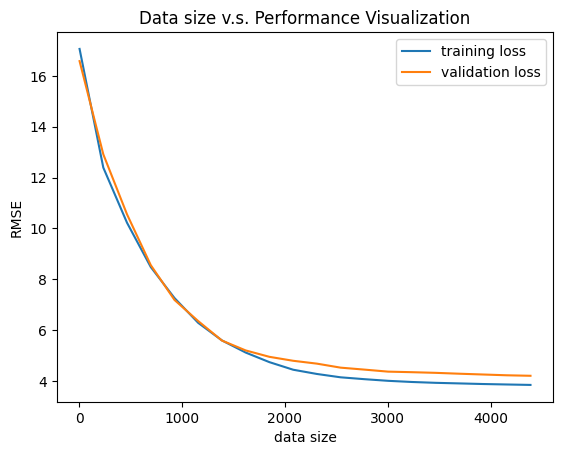

In [6]:
sizes = np.linspace(1, trainX.shape[0], 20)
training_loss = list()
validation_loss = list()

for size in sizes:
    model = LinearRegression()
    model.fit(
        trainX[:int(size)], 
        trainY[:int(size)], 
        lr=lr, 
        epochs=epochs, 
        batch_size=batch_size
    )
    training_loss.append(model.evaluate(trainX, trainY))
    validation_loss.append(model.evaluate(validX, validY))
    
plt.figure()
plt.plot(sizes, training_loss, label='training loss')
plt.plot(sizes, validation_loss, label='validation loss')
plt.title('Data size v.s. Performance Visualization')
plt.ylabel('RMSE')
plt.xlabel('data size')
plt.legend()
plt.show()

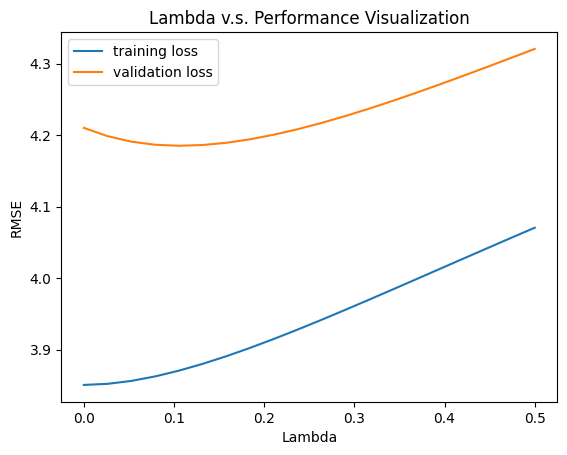

In [7]:
lambds = np.linspace(0, 0.5, 20)
training_loss = list()
validation_loss = list()

for lambd in lambds:
    model = LinearRegression()
    model.fit(
        trainX, 
        trainY, 
        lr=lr, 
        lambd=lambd,
        epochs=epochs, 
        batch_size=batch_size
    )
    training_loss.append(model.evaluate(trainX, trainY))
    validation_loss.append(model.evaluate(validX, validY))
    
plt.figure()
plt.plot(lambds, training_loss, label='training loss')
plt.plot(lambds, validation_loss, label='validation loss')
plt.title('Lambda v.s. Performance Visualization')
plt.ylabel('RMSE')
plt.xlabel('Lambda')
plt.legend()
plt.show()

In [11]:
X = np.concatenate([trainX, validX])
y = np.concatenate([trainY, validY])

model.fit(
    X, y, 
    lr=lr, 
    epochs=epochs,
    lambd=lambd,
    batch_size=batch_size
)

df = pd.read_csv('test_X.csv', header=None)
df.rename(columns={df.columns[0]: 'Index'}, inplace=True)
df['Index'] = df['Index'].apply(
    lambda x: f"index_{int(x.split('_')[1]):03d}"
)

testX = list()
for index, sdf in df.groupby('Index'):
    unit = np.array(sdf.iloc[:, 2:])
    unit = missingValueImputation(unit)
    unit = (unit - mean) / std
    testX.append([unit.flatten()])

testX = np.concatenate(testX)
print(f"Testing data size : {testX.shape}")

predY = model.predict(testX)
df = pd.DataFrame({
    'index': [f'index_{i}' for i in range(len(predY))],
    'answer': np.round(predY)
})

df.to_csv('result.csv', index=False)

Testing data size : (244, 162)
